# GISPR Module 2 — Spatial Foundations
## Spatial Libraries, Coding Structures, ESRI Tools, and Version Control

**Course:** GIS Spatial Analysis with Python and R (GISPR)  
**Module:** 2 — Building a Repeatable Workflow  
**Builds on:** Module 1 — variables, data frames, functions, packages, first geometry

---

### How to use this notebook

This notebook is designed for use in a **JupyterLab environment with two kernels available**:

- 🔵 **Cells marked `[R]`** — switch your kernel to **R** before running
- 🟢 **Cells marked `[Python]`** — switch your kernel to **Python 3** (or your cloned ArcGIS Pro env) before running
- 📋 **Cells marked `[Terminal]`** — paste the command into your **terminal / Anaconda Prompt**, not into a notebook cell

Each section has:
1. A brief concept explanation with a comparison table where relevant
2. Code demos to run and observe — side by side in R and Python
3. A **🔧 Try it yourself** prompt to apply the concept

The homework sections at the end are what you will **submit** as your Module 2 deliverable.

---

**Sections in this notebook:**
1. The Motivating Problem — what breaks without this module's skills
2. The Spatial Library Ecosystem — open-source and ESRI tools side by side
3. Clone the ArcGIS Pro Python Environment S
4. Set up the R ArcGIS Bridge
5. Loops and Conditionals — make code do the repetitive work
6. Writing Reusable Functions
7. Version Control — Git and GitHub
8. Mini End-to-End Workflow — tying it all together
9. 📋 Homework — Part A: Environment and Libraries
10. 📋 Homework — Part B: Loops, Functions, and a Workflow
11. 📋 Homework — Part C: Version Control

> **The goal isn't to memorize syntax.** It's to build the habit: load → inspect → process → document → save → commit.

---
## Section 1 — The Motivating Problem

Before we cover any new syntax, here's the scenario that ties this whole module together.

**You've just been handed a folder with these files:**

```
/project/
  watersheds_WA.shp          ← from state agency
  monitoring_points.csv      ← lat/lon from a field crew, no CRS documented
  landcover_2022.tif         ← raster, unknown projection
  analysis_v3_FINAL.py       ← someone else's script, last run "sometime in March"
  analysis_v3_FINAL_new.py   ← same script? different? no one remembers
```

Your task: reproduce a suitability analysis that combines all three datasets. The last person to run it left the team.

**What goes wrong without this module's skills:**
- You can't tell which script is current → you waste an afternoon running the wrong one
- The CSV loads but there's no spatial reference → the points land in the ocean
- The shapefile and raster don't align → spatial joins return empty results silently
- You fix it, but can't reproduce which steps you took → QA review fails

**What you'll be able to do by the end of this module:**

| Problem | Solution covered here |
|---|---|
| Which script is current? | Git version control — every change is logged |
| CSV loads but lands in the ocean | Load spatial libs correctly; assign CRS from coordinate columns |
| Datasets don't align | Check and reproject CRS before joining — sanity-check habit |
| Can't reproduce steps | Functions + documented notebooks + committed code |
| Library installs broke ArcGIS Pro | Cloned Python environment keeps Pro safe |

Keep this scenario in mind as you work through the sections. Every skill here solves a specific part of it.

---
## Section 2 — The Spatial Library Ecosystem

In Module 1 you saw the package landscape at a high level. This section makes it concrete: what each major library actually does, how the ESRI and open-source tools relate, and which one to reach for in different situations.

### The full stack at a glance

| Layer | Python | R |
|---|---|---|
| **Vector (open-source)** | `geopandas`, `shapely` | `sf` |
| **Raster (open-source)** | `rasterio`, `xarray` | `terra`, `stars` |
| **Visualization** | `matplotlib`, `folium` | `ggplot2`, `tmap`, `leaflet` |
| **ESRI — geoprocessing** | `arcpy` (inside ArcGIS Pro) | `arcgisbinding` (R-ArcGIS Bridge) |
| **ESRI — platform/cloud** | `arcgis` (ArcGIS API for Python) | `arcgislayers` |
| **Data wrangling** | `pandas`, `numpy` | `dplyr`, `tidyr`, `tibble` |

> **Rule of thumb:** Start with `arcpy` / `arcgisbinding` when your data lives in a geodatabase or you need ArcGIS Pro toolbox tools. Use `GeoPandas` / `sf` when you want open, portable, reproducible code that runs anywhere.

### 2a — Verify your spatial library stack

Run both cells below to confirm your environment has everything this course needs. If a library fails to import, the error message will tell you what to install.

In [ ]:
# [Python] Verify the open-source spatial stack

import importlib, sys

required = [
    "geopandas",
    "pandas",
    "numpy",
    "shapely",
    "rasterio",
    "matplotlib",
    "pyproj",
]

print(f"Python: {sys.version.split()[0]}")
print("-" * 40)
for pkg in required:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "(no version attr)")
        print(f"  ✓  {pkg:<18} {ver}")
    except ImportError:
        print(f"  ✗  {pkg:<18} NOT INSTALLED — run: pip install {pkg}")

# ── ArcGIS ecosystem (available inside ArcGIS Pro or cloned env) ──
print("\n── ESRI packages ──")
for pkg in ["arcpy", "arcgis"]:
    try:
        importlib.import_module(pkg)
        print(f"  ✓  {pkg}")
    except ImportError:
        print(f"  –  {pkg}  (only available inside ArcGIS Pro environment — expected if running elsewhere)")

Python: 3.12.12
----------------------------------------
  ✓  geopandas          1.1.1
  ✓  pandas             2.3.3
  ✓  numpy              2.3.5
  ✓  shapely            2.1.2
  ✓  rasterio           1.4.3
  ✓  matplotlib         3.10.8
  ✓  pyproj             3.7.2

── ESRI packages ──
  –  arcpy  (only available inside ArcGIS Pro environment — expected if running elsewhere)
  –  arcgis  (only available inside ArcGIS Pro environment — expected if running elsewhere)


In [ ]:
# [R] Verify the open-source spatial stack in R

required_pkgs <- c("sf", "terra", "dplyr", "tidyr", "ggplot2", "tmap", "leaflet")

cat(sprintf("R version: %s\n", R.version.string))
cat(strrep("-", 40), "\n")

for (pkg in required_pkgs) {
  if (requireNamespace(pkg, quietly = TRUE)) {
    ver <- as.character(packageVersion(pkg))
    cat(sprintf("  ✓  %-20s %s\n", pkg, ver))
  } else {
    cat(sprintf("  ✗  %-20s NOT INSTALLED — run: install.packages('%s')\n", pkg, pkg))
  }
}

# ── R-ArcGIS Bridge ──
cat("\n── ESRI packages ──\n")
if (requireNamespace("arcgisbinding", quietly = TRUE)) {
  cat(sprintf("  ✓  arcgisbinding  %s\n", packageVersion("arcgisbinding")))
} else {
  cat("  –  arcgisbinding  NOT FOUND — install from: https://r.esri.com\n")
}
if (requireNamespace("arcgislayers", quietly = TRUE)) {
  cat(sprintf("  ✓  arcgislayers   %s\n", packageVersion("arcgislayers")))
} else {
  cat("  –  arcgislayers   NOT FOUND — run: install.packages('arcgislayers')\n")
}

R version: R version 4.5.0 (2025-04-11 ucrt)
---------------------------------------- 
  ✓  sf                   1.0.24
  ✓  terra                1.8.93
  ✓  dplyr                1.2.0
  ✓  tidyr                1.3.2
  ✓  ggplot2              4.0.2
  ✗  tmap                 NOT INSTALLED — run: install.packages('tmap')
  ✓  leaflet              2.2.3

── ESRI packages ──
  ✓  arcgisbinding  1.0.1.311
  ✓  arcgislayers   0.5.2


### 2b — What each ESRI tool does (and when to use it)

Before working with code, it helps to understand what each tool in the ESRI Python and R ecosystem is actually for.

**Python side:**

| Tool | What it is | When to reach for it |
|---|---|---|
| `arcpy` | Full ArcGIS Pro toolbox from Python — geoprocessing, batch processing, field calcs, cursors | Your data is in a geodatabase; you want to automate ArcGIS Pro toolbox workflows |
| `arcgis` (ArcGIS API for Python) | REST-based access to the ArcGIS platform — query and publish hosted layers, work with ArcGIS Online and Enterprise | You need to pull data from ArcGIS Online, update a feature service, or use Spatially Enabled DataFrames |
| Spatially Enabled DataFrame (SeDF) | A `pandas` DataFrame with a geometry column — the ArcGIS API's equivalent of a GeoDataFrame | Bridge between `arcpy` / ArcGIS Online and open-source `pandas` workflows |

**R side:**

| Tool | What it is | When to reach for it |
|---|---|---|
| `arcgisbinding` (R-ArcGIS Bridge) | Two-way data exchange between R and ArcGIS Pro — read feature classes into R, write R results back to geodatabase, call R from ModelBuilder | Your data is in a geodatabase and you want to analyze it with R |
| `arcgislayers` | Access ArcGIS feature services from R via REST API, returning `sf` objects | You need to read/write ArcGIS Online hosted layers without ArcGIS Pro installed |

In [ ]:
# [Python] arcpy — load and inspect a feature class from a geodatabase
# Run this cell inside ArcGIS Pro (ArcGIS Notebook or Python window)
# It will NOT run in a standalone Jupyter session outside ArcGIS Pro

import arcpy

# arcpy.env.workspace points to your default geodatabase or a folder
arcpy.env.workspace = arcpy.env.activeDataset   # your current Pro project GDB

# List all feature classes in the workspace
fcs = arcpy.ListFeatureClasses()
print("Feature classes in workspace:")
for fc in fcs:
    desc = arcpy.Describe(fc)
    print(f"  {fc:<30} {desc.shapeType:<12} CRS: {desc.spatialReference.name}")

# If your workspace has no feature classes, this cell will print an empty list —
# that's fine. The key is that arcpy imported and ran without error.

In [ ]:
# [Python] ArcGIS API for Python — connect to ArcGIS Online and browse items
# This works outside ArcGIS Pro, in your cloned environment, as long as arcgis is installed

from arcgis.gis import GIS

# Anonymous connection — access public content only
gis = GIS()
print(f"Connected as: {gis.properties.user.username if gis.users.me else 'anonymous'}")

# Search for a publicly available feature layer
results = gis.content.search(
    query="US States boundaries",
    item_type="Feature Layer",
    max_items=3
)

print("\nPublic feature layers found:")
for item in results:
    print(f"  {item.title[:50]:<52} | {item.type} | owner: {item.owner}")

# To load one of these as a Spatially Enabled DataFrame:
# from arcgis.features import FeatureLayer
# lyr = FeatureLayer(results[0].url)
# sdf = lyr.query().sdf   # sdf = Spatially Enabled DataFrame
# print(sdf.head())

In [ ]:
# [R] R-ArcGIS Bridge — read a feature class from a geodatabase into R
# Requires arcgisbinding installed and ArcGIS Pro licensed on the same machine

library(arcgisbinding)
arc.check_product()   # confirms your ArcGIS Pro license is available

# Replace the path below with a real .gdb path on your machine
# gdb_path <- "C:/GIS/data/MyProject.gdb/watersheds"
# data_arc <- arc.open(gdb_path)
# df       <- arc.select(data_arc)   # returns a data.frame
# sf_layer <- arc.data2sf(df)        # convert to sf object
# print(sf_layer)

# ── Without a real GDB, demonstrate arc.check_product() output ──
# The key check is that the function returns without error and shows your license level
cat("R-ArcGIS Bridge version:", as.character(packageVersion("arcgisbinding")), "\n")
cat("arc.check_product() confirms your ArcGIS Pro license is accessible from R.\n")
cat("In a real workflow: arc.open() → arc.select() → arc.data2sf() → analyze with sf/tidyverse.\n")

*** Please call arc.check_product() to define a desktop license.


### 2c — Load and sanity-check spatial data (open-source workflow)

Whether the data came from a geodatabase, a feature service, or a downloaded file — before you touch it, you sanity-check it. This six-point checklist is the habit:

1. Did it load without errors?
2. How many features (rows)? How many attributes (columns)?
3. What geometry type? (Point / Line / Polygon?)
4. What CRS? Is it what you expected?
5. Does the bounding box make geographic sense?
6. Are there null or empty geometries?

We'll use a freely available dataset — US state boundaries — so there are no files to download.

To access larger datasets in this package, install the spDataLarge package with:
`install.packages('spDataLarge', repos='https://nowosad.github.io/drat/', type='source')`


Warning message:
package ‘spData’ was built under R version 4.5.3 


Class: sf, data.frame 
Features: 49 | Attributes: 7 
Columns: GEOID, NAME, REGION, AREA, total_pop_10, total_pop_15, geometry 
Geometry type: MULTIPOLYGON 
CRS (EPSG): 4269 
CRS name:   EPSG:4269 

Bounding box:
      xmin       ymin       xmax       ymax 
-124.70415   24.55868  -66.98240   49.38436 

Null/empty geometries: 0 


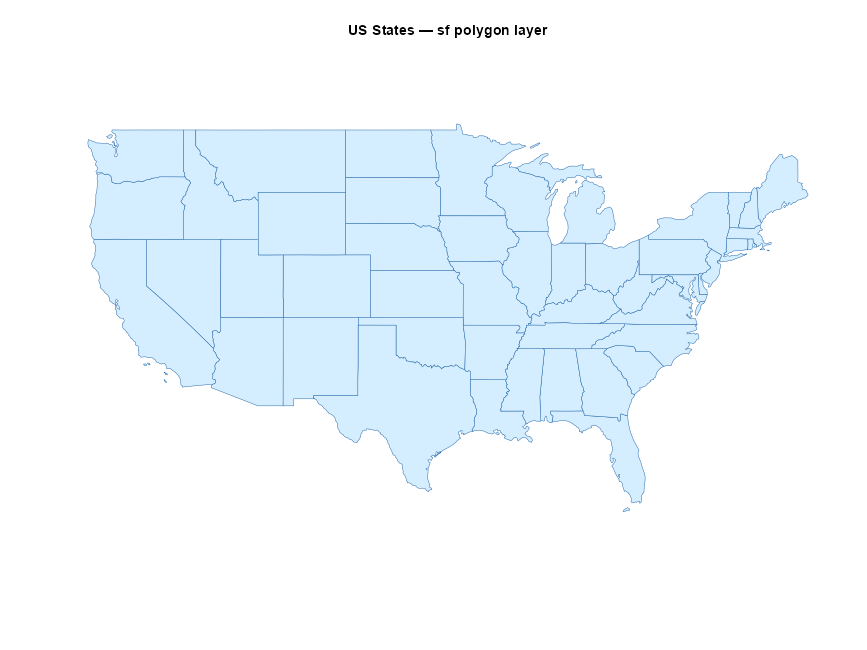

In [2]:
# [R] Load spatial data and run the full sanity-check sequence
# install.packages("spData")  # run once in your R console if needed

library(sf)
library(spData)   # ships with sample spatial datasets

states <- us_states   # sf object — polygon layer

# ── 1. Did it load? ───────────────────────────────────────────
cat("Class:", paste(class(states), collapse = ", "), "\n")

# ── 2. Dimensions ─────────────────────────────────────────────
cat("Features:", nrow(states), "| Attributes:", ncol(states), "\n")
cat("Columns:", paste(names(states), collapse = ", "), "\n")

# ── 3. Geometry type ──────────────────────────────────────────
cat("Geometry type:", as.character(unique(st_geometry_type(states))), "\n")

# ── 4. CRS ────────────────────────────────────────────────────
cat("CRS (EPSG):", st_crs(states)$epsg, "\n")
cat("CRS name:  ", st_crs(states)$input, "\n")

# ── 5. Bounding box ───────────────────────────────────────────
cat("\nBounding box:\n")
print(st_bbox(states))

# ── 6. Null/empty geometries ──────────────────────────────────
cat("\nNull/empty geometries:", sum(st_is_empty(states)), "\n")

# ── Quick plot ────────────────────────────────────────────────
plot(st_geometry(states),
     col = "#d4edff", border = "#185FA5", lwd = 0.6,
     main = "US States — sf polygon layer")

In [ ]:
# [Python] Load spatial data and run the full sanity-check sequence

import geopandas as gpd
import matplotlib.pyplot as plt

# Load world countries (built-in via geodatasets or geopandas)
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# ── 1. Did it load? ───────────────────────────────────────────
print(f"Type: {type(world).__name__}")

# ── 2. Dimensions ─────────────────────────────────────────────
print(f"Features: {len(world)} | Columns: {len(world.columns)}")
print(f"Columns: {world.columns.tolist()}")

# ── 3. Geometry type ──────────────────────────────────────────
print(f"Geometry types: {world.geometry.geom_type.unique()}")

# ── 4. CRS ────────────────────────────────────────────────────
print(f"CRS: {world.crs}")

# ── 5. Bounding box ───────────────────────────────────────────
print(f"Total bounds (xmin, ymin, xmax, ymax): {world.total_bounds.round(3)}")

# ── 6. Null/empty geometries ──────────────────────────────────
nulls = world.geometry.is_empty.sum() + world.geometry.isna().sum()
print(f"Null/empty geometries: {nulls}")

# ── Quick plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
world.plot(ax=ax, color="#d4edff", edgecolor="#185FA5", linewidth=0.4)
ax.set_title("World Countries — GeoPandas polygon layer (EPSG:4326)")
plt.tight_layout()
plt.show()

### 2d — Reading common file formats

In practice you will load your own files. Here's the syntax you'll reuse throughout the course.

In [3]:
# [R] Reading common spatial file formats with sf

library(sf)

# Shapefile (.shp + sidecar files must all be present)
# layer <- st_read("path/to/watersheds.shp")

# GeoJSON
# layer <- st_read("path/to/parcels.geojson")

# GeoPackage (preferred open format — single file)
# layer <- st_read("path/to/data.gpkg", layer = "watersheds")

# File geodatabase (read-only via sf/GDAL)
# layer <- st_read("path/to/MyProject.gdb", layer = "watersheds")

# URL — read directly from the web (GitHub raw, open data portals)
# layer <- st_read("https://raw.githubusercontent.com/.../data.geojson")

# After loading ANY file, run the sanity check immediately:
sanity_check_r <- function(layer, label = "layer") {
  cat("\n====" , label, "===\n")
  cat("Features:", nrow(layer), "| Cols:", ncol(layer), "\n")
  cat("Geometry:", as.character(unique(st_geometry_type(layer))), "\n")
  cat("CRS (EPSG):", st_crs(layer)$epsg, "\n")
  cat("Null geoms:", sum(st_is_empty(layer)), "\n")
}

# Example: built-in dataset through the same function
library(spData)
sanity_check_r(us_states, "US States")


==== US States ===
Features: 49 | Cols: 7 
Geometry: MULTIPOLYGON 
CRS (EPSG): 4269 
Null geoms: 0 


In [ ]:
# [Python] Reading common spatial file formats with GeoPandas

import geopandas as gpd

# Shapefile
# layer = gpd.read_file("path/to/watersheds.shp")

# GeoJSON
# layer = gpd.read_file("path/to/parcels.geojson")

# GeoPackage
# layer = gpd.read_file("path/to/data.gpkg", layer="watersheds")

# File geodatabase (read-only via GDAL)
# layer = gpd.read_file("path/to/MyProject.gdb", layer="watersheds")

# URL — direct from GitHub or open data portals
# layer = gpd.read_file("https://raw.githubusercontent.com/.../data.geojson")

# Reusable sanity-check function — call this on every dataset you load
def sanity_check(gdf, label="layer"):
    """Print key properties of a GeoDataFrame."""
    print(f"\n==== {label} ====")
    print(f"Features: {len(gdf)} | Columns: {len(gdf.columns)}")
    print(f"Geometry types: {gdf.geometry.geom_type.unique()}")
    print(f"CRS: {gdf.crs}")
    nulls = gdf.geometry.is_empty.sum() + gdf.geometry.isna().sum()
    print(f"Null/empty geometries: {nulls}")
    print(f"Bounds: {gdf.total_bounds.round(3)}")

world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
sanity_check(world, "World Countries")

### 🔧 Try it yourself — Libraries and loading
1. Find any shapefile or GeoJSON from your local government's open data portal (Seattle, King County, and most cities publish these for free). Download it.
2. Load it using `sf` (R) or `GeoPandas` (Python) and run the sanity-check function.
3. Does the CRS look right? Does the bounding box match where you'd expect the data to be geographically?
4. What geometry type is it? Does that match what you'd expect for this dataset?

---
## Section 3 — Clone the ArcGIS Pro Python Environment

ArcGIS Pro ships with a **read-only** base Python environment called `arcgispro-py3`. If you install packages directly into it, a Pro update can break your installs — or worse, break Pro itself.

The solution: **clone** the base environment and work in your clone. Your clone gets all the arcpy goodness, but you can install whatever you need without risk.

```
arcgispro-py3 (base — read-only, never modify)
      │
      └── gispr (your clone — safe to install packages here)
```

> **If you're not running ArcGIS Pro on this machine:** skip to Section 3c and use the Miniforge / conda-forge approach instead.

### 3a — Clone via the ArcGIS Pro GUI (easiest)

1. Open **ArcGIS Pro**
2. Go to **Project → Python** (left ribbon)
3. Click **Manage Environments**
4. In the **Active Environment** dropdown, click **Clone Default**
5. Name the clone `gispr` — choose a location on your drive (not inside Program Files)
6. Click **OK** and wait — this takes 5–15 minutes
7. Set `gispr` as your **Active Environment** and restart Pro

### 3b — Clone via the command line (reproducible)

Run the cells below in your **terminal / Anaconda Prompt**, not in this notebook.

In [ ]:
# [Terminal] Step 1: Find the ArcGIS Pro base environment path
# Windows default — adjust if ArcGIS Pro is installed elsewhere:
#   C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3

# List all conda environments so you can confirm the path:
# conda env list

In [ ]:
# [Terminal] Step 2: Clone the base environment
# Replace the path with your actual ArcGIS Pro env location

# Windows:
# conda create --name gispr --clone "C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3"

# macOS / Linux (if Pro is not installed — clone from a plain conda base instead):
# conda create --name gispr python=3.11
# conda install -n gispr -c conda-forge geopandas rasterio shapely

In [ ]:
# [Terminal] Step 3: Activate and verify your new environment

# conda activate gispr
# python --version
# conda info              # shows active environment path
# python -c "import arcpy; print(arcpy.GetInstallInfo()['Version'])"  # should print Pro version
# python -c "import geopandas; print(geopandas.__version__)"           # should print version

In [ ]:
# [Terminal] Step 4: Install additional packages into YOUR environment
# Never run pip install or conda install in arcgispro-py3 — always activate gispr first

# conda activate gispr

# Install packages from conda-forge (preferred for geospatial dependencies):
# conda install -c conda-forge folium xarray netCDF4 jupyter

# Or with pip (for packages not on conda-forge):
# pip install geodatasets

In [ ]:
# [Python] Verify you are running in the correct environment
# Switch your JupyterLab kernel to 'gispr', then run this cell

import sys
import os

print(f"Python version:    {sys.version.split()[0]}")
print(f"Environment path:  {sys.prefix}")
print(f"Environment name:  {os.path.basename(sys.prefix)}")

# Confirm arcpy is accessible (only works if this is a cloned ArcGIS Pro env)
try:
    import arcpy
    print(f"arcpy version:     {arcpy.GetInstallInfo()['Version']}")
    print("✓ ArcGIS Pro environment confirmed — arcpy is available.")
except ImportError:
    print("– arcpy not available in this environment (expected if not a Pro clone).")

# Confirm open-source packages
import geopandas as gpd
print(f"geopandas version: {gpd.__version__}")
print("✓ Open-source spatial stack confirmed.")

### 3c — If you're NOT using ArcGIS Pro: Miniforge setup

If ArcGIS Pro isn't available on this machine, use **Miniforge** — a lightweight conda distribution with excellent geospatial package coverage:

1. Download Miniforge: https://github.com/conda-forge/miniforge
2. Install and open the Miniforge Prompt
3. Create the course environment:

```bash
conda create -n gispr python=3.11
conda activate gispr
conda install -c conda-forge geopandas rasterio shapely xarray folium jupyter
pip install arcgis   # ArcGIS API for Python — works outside Pro
```

### 🔧 Try it yourself — Environment
1. Clone the ArcGIS Pro environment using the GUI (method 3a) or command line (method 3b).
2. Switch your JupyterLab kernel to `gispr` and run the verification cell above.
3. What is the full path to your `gispr` environment? Note it down — you'll need it when switching kernels.
4. Install one package that wasn't in the base environment (e.g., `folium`) and verify it imports correctly.

---
## Section 4 — Installing the R-ArcGIS Bridge (`arcgisbinding`)

> ⚠️ **Local-only section — does not run in JupyterHub**
>
> The cells in this section require **local RStudio or Positron** on a machine with a licensed copy of **ArcGIS Pro** installed. They cannot run in the course JupyterHub environment.
>
> **You do not need to complete these cells in the notebook.** Instead, try each step in your local RStudio or Positron R console. If you don't yet have ArcGIS Pro available locally, read through the steps so you know the workflow — we will revisit the bridge in a later module.

### What is the R-ArcGIS Bridge?

The `arcgisbinding` package is ESRI's official R package that creates a two-way link between R and ArcGIS Pro:

| Direction | What you can do |
|---|---|
| ArcGIS Pro → R | Read feature classes, tables, and rasters directly into R (`arc.open()`, `arc.select()`) |
| R → ArcGIS Pro | Write R results (sf objects, data frames) back to geodatabases (`arc.write()`) |
| ModelBuilder ↔ R | Call R scripts as geoprocessing tools from ArcGIS ModelBuilder |

This is particularly powerful for workflows where your data lives in an enterprise geodatabase but you want to do the analysis in R's tidyverse ecosystem.

### Step 1 — Install `arcgisbinding` from ESRI's R package repository

Run the following in your **local RStudio or Positron** R console (not in this notebook):

#### Method 1: Using ArcGIS Pro (Recommended)
1. Open ArcGIS Pro and go to Project > Options.
2. On the left-side panel, select Geoprocessing.
3. Under the R-ArcGIS Support options, use the drop-down menu to select your R home directory (install the latest version of R if you haven't already).
4. You will see a warning that arcgisbinding needs to be installed. Click the Install Icon next to the warning.
5. Select Install package from the Internet and click Yes

#### Method 2: Run the following in your local RStudio or Positron R console (not in this notebook):

In [ ]:
# ============================================================
# LOCAL ONLY — Run in RStudio or Positron on a machine with ArcGIS Pro
# This cell will NOT run in JupyterHub.
# ============================================================

# [R] Step 1: Install arcgisbinding from ESRI's R package repository
# install.packages(
#   "arcgisbinding",
#   repos = "https://r.esri.com",
#   type  = "win.binary"   # Windows; remove this argument on Mac/Linux
# )

# Verify the install:
# library(arcgisbinding)
# arc.check_product()   # Should print your ArcGIS Pro version and license status

### Step 2 — Bind the bridge to your ArcGIS Pro installation

`arc.check_product()` verifies that R can see a licensed ArcGIS Pro installation. You must run this once per R session before using any `arc.*` functions.

In [ ]:
# ============================================================
# LOCAL ONLY — Run in RStudio or Positron on a machine with ArcGIS Pro
# This cell will NOT run in JupyterHub.
# ============================================================

# [R] Step 2: Load and bind the bridge in a fresh R session
# library(arcgisbinding)
# arc.check_product()   # Run once per session — checks ArcGIS Pro license

# ── Read a feature class from a geodatabase into R ───────────
# Replace the path below with a real geodatabase and feature class on your machine:
# fc_path <- "C:/path/to/your/project.gdb/YourFeatureClass"
# fc      <- arc.open(fc_path)
# df      <- arc.select(fc)   # loads as a data frame

# ── Convert to sf for tidyverse-compatible spatial analysis ──
# library(sf)
# sf_layer <- arc.data2sf(df)   # arcgisbinding data frame → sf object
# print(sf_layer)
# plot(st_geometry(sf_layer))

# ── Write results back to a geodatabase ──────────────────────
# out_path <- "C:/path/to/your/project.gdb/OutputFeatureClass"
# arc.write(out_path, sf_layer)   # sf object → ArcGIS feature class

### Why bother with the bridge vs. `arcgislayers`?

| | `arcgisbinding` | `arcgislayers` |
|---|---|---|
| **Requires ArcGIS Pro locally** | ✅ Yes | ❌ No |
| **Reads local geodatabases** | ✅ Yes | ❌ No (REST only) |
| **Writes back to .gdb** | ✅ Yes | Limited |
| **Works in JupyterHub** | ❌ No | ✅ Yes |
| **ModelBuilder integration** | ✅ Yes | ❌ No |
| **ArcGIS Online access** | Via Pro | ✅ Direct |

**Rule of thumb:** Use `arcgisbinding` when your data lives in a local or enterprise geodatabase. Use `arcgislayers` when your data is in ArcGIS Online or you're working on a machine without ArcGIS Pro (including JupyterHub).

> **Reminder:** Try the cells above in your local RStudio or Positron — you don't need to run them here. Post in Ed Discussion with a screenshot of `arc.check_product()` output if you want to confirm your setup is working.

---
## Section 5 — Loops and Conditionals: Make Code Do the Repetitive Work

In GIS you rarely process one feature. You process hundreds or thousands — and you want consistent rules applied to all of them. Loops and conditionals let you encode those rules once and apply them automatically.

**The translation table:**

| Concept | R | Python |
|---|---|---|
| For loop | `for (item in collection) { }` | `for item in collection:` |
| Conditional | `if (cond) { } else if { } else { }` | `if cond: ... elif ...: ... else:` |
| Apply over vector | `sapply(x, func)` / `purrr::map()` | `[func(x) for x in list]` |
| Vectorized column op | `dplyr::case_when()` | `np.select()` / `pd.cut()` |

> **R philosophy:** avoid explicit loops where possible — use vectorized operations or `apply` family functions. **Python philosophy:** list comprehensions and `pandas` vectorized ops are preferred over `for` loops on large datasets. We'll show both.

In [ ]:
# [R] Loops and conditionals — classify states by population tier

library(sf)
library(spData)
library(dplyr)

states <- us_states

# ── Explicit for loop: flag states over 10 million people ─────
large_states <- c()
for (i in seq_len(nrow(states))) {
  pop <- states$total_pop_15[i]
  if (!is.na(pop) && pop > 10000000) {
    large_states <- c(large_states, states$NAME[i])
  }
}
cat("States with pop > 10M (loop approach):")
cat("\n ", paste(large_states, collapse = ", "), "\n")

# ── Vectorized alternative: dplyr::case_when (idiomatic R) ────
states <- states |>
  mutate(
    pop_tier = case_when(
      total_pop_15 >= 10000000 ~ "large",
      total_pop_15 >=  3000000 ~ "medium",
      total_pop_15 >=  1000000 ~ "small",
      TRUE                     ~ "micro"
    )
  )

cat("\nPop tier breakdown:\n")
print(table(states$pop_tier))

# Quick map colored by tier
plot(states["pop_tier"],
     main = "US States by Population Tier",
     border = "white", lwd = 0.3)

In [ ]:
# [Python] Loops and conditionals — classify countries by population tier

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# ── Explicit loop with iterrows() — readable but slow on large data ──
large_countries = []
for idx, row in world.iterrows():
    if row["pop_est"] > 100_000_000:
        large_countries.append(row["name"])

print(f"Countries with pop > 100M (loop): {len(large_countries)}")
print(", ".join(sorted(large_countries)))

# ── Vectorized alternative: np.select — preferred for DataFrames ──
conditions = [
    world["pop_est"] >= 100_000_000,
    world["pop_est"] >=  50_000_000,
    world["pop_est"] >=  10_000_000,
]
world["pop_tier"] = np.select(
    conditions,
    ["large", "medium", "small"],
    default="micro"
)

print("\nPop tier breakdown:")
print(world["pop_tier"].value_counts())

# Map colored by tier
fig, ax = plt.subplots(figsize=(10, 4))
world.plot(ax=ax, column="pop_tier", legend=True,
           cmap="Set2", edgecolor="white", linewidth=0.3,
           missing_kwds={"color": "lightgray"})
ax.set_title("Countries by Population Tier")
plt.tight_layout()
plt.show()

### 🔧 Try it yourself — Loops and conditionals
1. Add a column `area_tier` that classifies features by **geometry area** into `"large"`, `"medium"`, and `"small"`. Use `st_area()` in R (after projecting to an equal-area CRS) or `.area` in Python after `.to_crs("EPSG:6933")`.
2. Using a `for` loop, print the name of every feature where your two tier columns disagree (a large-pop country that is small-area, for example). How many are there?
3. Try the same classification using the vectorized approach (`case_when` in R or `np.select` in Python). Do the results match?

---
## Section 6 — Writing Reusable Functions

The rule: **if you write the same block of code twice, it should be a function.** Functions are how you turn a one-off analysis into a reusable tool — and they're the foundation of any automated spatial workflow.

**Function anatomy:**

| Concept | R | Python |
|---|---|---|
| Define | `my_func <- function(arg1, arg2 = default) { }` | `def my_func(arg1, arg2=default):` |
| Return value | last expression or `return(x)` | `return x` |
| Docstring | comment block above | triple-quoted string inside `def` |
| Apply over vector | `sapply(vec, my_func)` | `[my_func(x) for x in vec]` or `df.apply()` |

In [ ]:
# [R] Three reusable functions — written once, called many times

library(sf)
library(spData)
library(dplyr)

# ── Function 1: Sanity check (reusable across any sf layer) ──────
sanity_check_sf <- function(layer, label = "layer") {
  cat("\n====" , label, "====\n")
  cat("  Features:", nrow(layer), "| Cols:", ncol(layer), "\n")
  cat("  Geometry:", as.character(unique(st_geometry_type(layer))), "\n")
  cat("  CRS EPSG:", st_crs(layer)$epsg, "\n")
  cat("  Null geoms:", sum(st_is_empty(layer)), "\n")
  invisible(layer)   # return the layer so the function can be piped
}

# ── Function 2: Standardize a text attribute column ─────────────
# Useful before joins — lowercase + no extra whitespace
standardize_text <- function(x) {
  x <- trimws(tolower(as.character(x)))
  gsub("\\s+", "_", x)   # spaces to underscores
}

# ── Function 3: Compute population density ──────────────────────
# Projects to equal-area, computes area in km², returns density
pop_density <- function(layer, pop_col, crs_ea = 6933) {
  projected  <- st_transform(layer, crs = crs_ea)
  area_km2   <- as.numeric(st_area(projected)) / 1e6
  round(layer[[pop_col]] / area_km2, 2)
}

# ── Apply all three functions ────────────────────────────────────
states <- us_states
sanity_check_sf(states, "US States (raw)")

states <- states |>
  mutate(
    name_clean  = standardize_text(NAME),
    pop_density = pop_density(states, "total_pop_15")
  )

cat("\nTop 5 states by population density (per km²):\n")
top5 <- states |>
  st_drop_geometry() |>
  select(NAME, total_pop_15, pop_density) |>
  arrange(desc(pop_density)) |>
  head(5)
print(top5)

sanity_check_sf(states, "US States (processed)")

In [ ]:
# [Python] Three reusable functions — written once, called many times

import geopandas as gpd
import pandas as pd
import re

# ── Function 1: Sanity check (reusable across any GeoDataFrame) ──
def sanity_check(gdf, label="layer"):
    """Print key properties of a GeoDataFrame. Returns gdf for chaining."""
    print(f"\n==== {label} ====")
    print(f"  Features: {len(gdf)} | Columns: {len(gdf.columns)}")
    print(f"  Geometry types: {gdf.geometry.geom_type.unique()}")
    print(f"  CRS: {gdf.crs}")
    nulls = gdf.geometry.is_empty.sum() + gdf.geometry.isna().sum()
    print(f"  Null/empty geometries: {nulls}")
    return gdf

# ── Function 2: Standardize a text column ───────────────────────
def standardize_text(text):
    """Lowercase, strip whitespace, replace spaces with underscores."""
    if pd.isna(text):
        return None
    text = str(text).lower().strip()
    return re.sub(r"\s+", "_", text)

# ── Function 3: Compute population density ──────────────────────
def pop_density(gdf, pop_col, epsg_ea=6933):
    """Return population density in pop/km², using an equal-area projection."""
    projected = gdf.to_crs(epsg=epsg_ea)
    area_km2  = projected.geometry.area / 1e6
    return (gdf[pop_col] / area_km2).round(2)

# ── Apply all three functions ────────────────────────────────────
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
sanity_check(world, "World Countries (raw)")

world["name_clean"]  = world["name"].apply(standardize_text)
world["pop_density"] = pop_density(world, "pop_est")

print("\nTop 5 countries by population density (pop/km²):")
print(
    world[["name", "pop_est", "pop_density"]]
    .sort_values("pop_density", ascending=False)
    .head(5)
    .to_string(index=False)
)
sanity_check(world, "World Countries (processed)")

### 🔧 Try it yourself — Functions
1. Write a function `classify_density(density_value)` that returns `"dense"`, `"moderate"`, or `"sparse"` based on thresholds you choose. Apply it to the `pop_density` column you computed above.
2. Write a function `check_crs(layer, expected_epsg)` that returns `True` if the layer's CRS matches the expected EPSG and `False` (with a warning message) if it doesn't. Call it on two different layers.
3. Modify the `sanity_check` function to also print the first 3 column names and the min/max of the first numeric column it finds.

---
## Section 7 — Version Control: Git and GitHub

Remember the motivating problem from Section 1?

```
analysis_v3_FINAL.py
analysis_v3_FINAL_new.py
```

Git eliminates this entirely. Every change is logged with who made it, when, and why — and you can go back to any previous state.

**Why version control matters for GIS work specifically:**
- Track what changed between analysis runs when results look different
- Collaborate without overwriting each other's scripts
- Tag the exact code used for a deliverable — reproducibility for QA
- Branch to try a new approach without risking your working version

**The core Git workflow:**

```
Edit file  →  git add  →  git commit  →  git push  →  (teammates git pull)
(working)    (stage)     (snapshot)    (GitHub)       (sync)
```

> **Note:** Jupyter notebooks and some binary files don't diff cleanly in Git — version control works best with plain `.py`, `.R`, `.qmd`, and `.Rmd` files. Keep notebooks for exploration; extract finalized code into scripts for version-controlled workflows.

In [ ]:
# [Terminal] One-time Git configuration — do this once on each machine

# git config --global user.name  "Your Name"
# git config --global user.email "you@example.com"

# Verify:
# git config --list | grep user

In [ ]:
# [Terminal] Create a project folder and initialize a Git repository

# mkdir gispr-module2
# cd gispr-module2
# git init
# You'll see: Initialized empty Git repository in .../gispr-module2/.git/

In [ ]:
# [Terminal] Create a .gitignore to keep large geodata files out of Git
# Git is for CODE, not 500 MB geodatabases

# On macOS/Linux:
# cat > .gitignore << 'EOF'
# # Geodata — track code, not data
# *.shp
# *.dbf
# *.shx
# *.prj
# *.tif
# *.gpkg
# *.gdb/
# *.nc
# # Python
# __pycache__/
# .ipynb_checkpoints/
# *.pyc
# # R
# .Rhistory
# .RData
# *.Rproj.user/
# # OS
# .DS_Store
# Thumbs.db
# EOF

# On Windows (PowerShell):
# Copy the lines above manually into a new file named exactly: .gitignore

In [ ]:
# [Terminal] The core Git loop — run this after every meaningful change

# 1. See what changed:
# git status

# 2. Stage the files you want to commit:
# git add analysis.py         # one file
# git add .                   # everything not in .gitignore

# 3. Commit with a clear message:
# git commit -m "Add pop_density function and classify states by tier"

# 4. Push to GitHub:
# git push

In [ ]:
# [Terminal] Connect your local repo to GitHub and push the first time

# First: create a NEW empty repository on github.com
#   → Profile → Repositories → New
#   → Name: gispr-module2
#   → DO NOT initialize with README (you already have local files)
#   → Copy the repo URL: https://github.com/yourusername/gispr-module2.git

# Then in your terminal:
# git remote add origin https://github.com/yourusername/gispr-module2.git
# git branch -M main
# git push -u origin main

# After the first push, subsequent pushes are just:
# git push

### Writing good commit messages

A commit message should tell Future You (and teammates) what changed and why — not just that something changed.

| ❌ Avoid | ✓ Prefer |
|---|---|
| `"updated stuff"` | `"Add pop_density function; classify states into 4 tiers"` |
| `"fixed it"` | `"Fix CRS mismatch: reproject to EPSG:32610 before area calc"` |
| `"wip"` | `"WIP: sanity_check function working, need to add bounding box check"` |
| `"changes"` | `"Refactor: extract sanity_check to shared_utils.py"` |

**Rule of thumb:** Future You should be able to read the commit log and understand what happened without opening the files.

### 🔧 Try it yourself — Git
1. Initialize a Git repo in your Module 2 project folder and create a `.gitignore`.
2. Make at least **3 meaningful commits** as you work — one after completing each section.
3. Connect to GitHub and push. Confirm the files appear in your browser.
4. Run `git log --oneline` and read your commit history. Does it tell the story of what you did?

---
## Section 8 — Mini End-to-End Workflow

All five skills from this module — libraries, environments, loops, functions, and Git — combine into one coherent pattern. This section shows the full loop on a small real dataset.

**Pattern:** load → sanity check → process (functions + loops) → visualize → save → commit

This is the same pattern you'll extend in every module from here on.

In [ ]:
# [Python] Full end-to-end: load, check, process, visualize, save

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ── 1. Load ───────────────────────────────────────────────────
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# ── 2. Sanity check ───────────────────────────────────────────
def sanity_check(gdf, label="layer"):
    print(f"\n==== {label} ====")
    print(f"  Features: {len(gdf)} | Cols: {len(gdf.columns)} | CRS: {gdf.crs}")
    nulls = gdf.geometry.is_empty.sum() + gdf.geometry.isna().sum()
    print(f"  Null/empty geoms: {nulls}")
    return gdf

sanity_check(world, "World (raw)")

# ── 3. Process — functions + vectorized ops ────────────────────
def standardize_text(text):
    if pd.isna(text): return None
    return re.sub(r"\s+", "_", str(text).lower().strip())

def pop_density(gdf, pop_col, epsg_ea=6933):
    projected = gdf.to_crs(epsg=epsg_ea)
    area_km2  = projected.geometry.area / 1e6
    return (gdf[pop_col] / area_km2).round(2)

world["name_clean"]  = world["name"].apply(standardize_text)
world["pop_density"] = pop_density(world, "pop_est")

conditions = [
    world["pop_density"] >= 200,
    world["pop_density"] >=  50,
    world["pop_density"] >=  10,
]
world["density_class"] = np.select(conditions, ["very dense", "dense", "moderate"], default="sparse")

sanity_check(world, "World (processed)")
print("\nDensity class breakdown:")
print(world["density_class"].value_counts())

# ── 4. Visualize ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
world.plot(ax=ax, column="pop_density",
           cmap="YlOrRd", legend=True,
           legend_kwds={"label": "Pop/km²", "shrink": 0.5},
           edgecolor="white", linewidth=0.2,
           missing_kwds={"color": "lightgray"})
ax.set_title("Population Density by Country (pop/km²)")
plt.tight_layout()
plt.savefig("output_density_map.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Save processed data ────────────────────────────────────
world.to_file("world_processed.gpkg", driver="GPKG")
print("\nSaved: world_processed.gpkg | output_density_map.png")
print("Next: git add . && git commit -m 'Add pop_density classification and choropleth map'")


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Warning message:
package ‘dplyr’ was built under R version 4.5.2 



==== US States (raw) ====
  Features: 49 | Cols: 7 | CRS: 4269 
  Null geoms: 0 

==== US States (processed) ====
  Features: 49 | Cols: 10 | CRS: 4269 
  Null geoms: 0 

Density class breakdown:

     dense   moderate     sparse very dense 
        15         20          8          6 


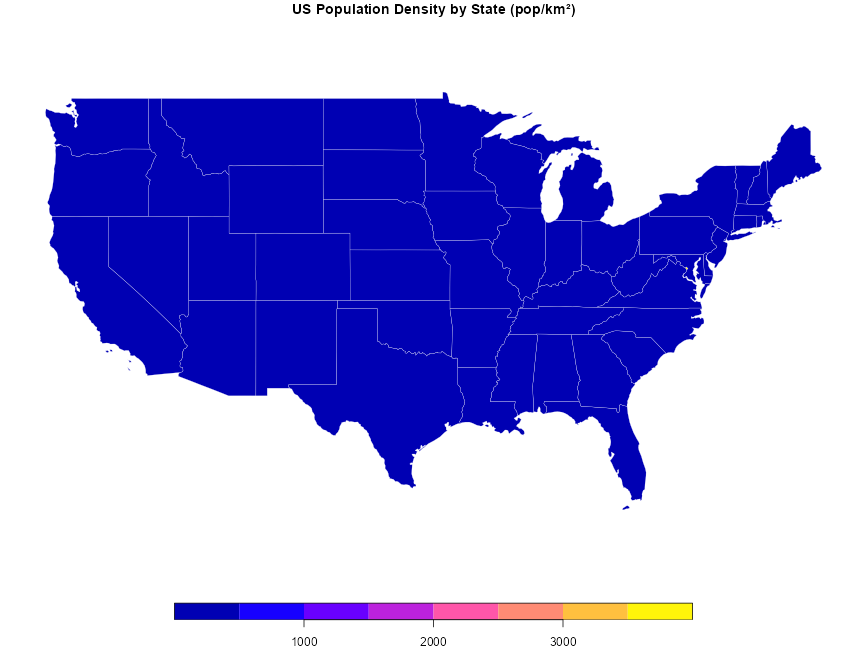

Deleting source `states_processed.gpkg' failed
Writing layer `states_processed' to data source `states_processed.gpkg' using driver `GPKG'
Writing 49 features with 9 fields and geometry type Multi Polygon.

Saved: states_processed.gpkg
Next: git add . && git commit -m 'Add pop_density classification and choropleth'


In [4]:
# [R] Full end-to-end: same workflow in R

library(sf)
library(spData)
library(dplyr)

# ── 1. Load ───────────────────────────────────────────────────
states <- us_states

# ── 2. Sanity check ───────────────────────────────────────────
sanity_check_sf <- function(layer, label = "layer") {
  cat("\n====", label, "====\n")
  cat("  Features:", nrow(layer), "| Cols:", ncol(layer),
      "| CRS:", st_crs(layer)$epsg, "\n")
  cat("  Null geoms:", sum(st_is_empty(layer)), "\n")
  invisible(layer)
}
sanity_check_sf(states, "US States (raw)")

# ── 3. Process ────────────────────────────────────────────────
pop_density_r <- function(layer, pop_col, crs_ea = 6933) {
  projected <- st_transform(layer, crs = crs_ea)
  area_km2  <- as.numeric(st_area(projected)) / 1e6
  round(layer[[pop_col]] / area_km2, 2)
}

states <- states |>
  mutate(
    name_clean    = trimws(tolower(NAME)),
    pop_density   = pop_density_r(states, "total_pop_15"),
    density_class = case_when(
      pop_density >= 200 ~ "very dense",
      pop_density >=  50 ~ "dense",
      pop_density >=  10 ~ "moderate",
      TRUE               ~ "sparse"
    )
  )

sanity_check_sf(states, "US States (processed)")
cat("\nDensity class breakdown:\n")
print(table(states$density_class))

# ── 4. Visualize ──────────────────────────────────────────────
plot(states["pop_density"],
     main   = "US Population Density by State (pop/km²)",
     border = "white", lwd = 0.3)

# ── 5. Save ───────────────────────────────────────────────────
st_write(states, "states_processed.gpkg", delete_dsn = TRUE)
cat("\nSaved: states_processed.gpkg\n")
cat("Next: git add . && git commit -m 'Add pop_density classification and choropleth'\n")

---
---
# 📋 Homework

The three sections below are your **Module 2 deliverable**. Complete them in this notebook (or in a companion `.R` / `.py` script), commit everything to your GitHub repo, and submit the repo link via Canvas.

**What you are submitting:**
- This notebook (or a companion script) with all homework cells completed and outputs visible
- A GitHub repository link with at least **3 meaningful commits**

Work through the sections in order — each one builds on the previous.

---
## 📋 Homework — Part A: Environment and Libraries

**Goal:** Demonstrate that your spatial computing environment is correctly configured and that you understand what each major library does.

### Task A1 — Environment verification screenshot

Run the verification cell below (adapted to your environment). Take a screenshot showing:
- The Python version and environment path
- All required open-source libraries successfully imported with version numbers
- Whether `arcpy` and/or `arcgis` are accessible

Paste the screenshot into your submission (or save it as `screenshots/env_verification.png` in your repo).

In [ ]:
# [Python] HOMEWORK A1 — Run this cell and screenshot the output

import sys, importlib

packages = ["geopandas", "pandas", "numpy", "shapely", "rasterio",
            "matplotlib", "pyproj", "arcpy", "arcgis"]

print(f"Python: {sys.version.split()[0]}  |  Env: {sys.prefix}")
print("-" * 55)
for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "ok")
        print(f"  ✓  {pkg:<20} {ver}")
    except ImportError:
        print(f"  ✗  {pkg:<20} not available")

In [ ]:
# [R] HOMEWORK A1 — Run this cell and screenshot the output

pkgs <- c("sf", "terra", "dplyr", "tidyr", "ggplot2",
           "tmap", "arcgisbinding", "arcgislayers")

cat(R.version.string, "\n")
cat(strrep("-", 50), "\n")
for (p in pkgs) {
  if (requireNamespace(p, quietly = TRUE)) {
    cat(sprintf("  ✓  %-20s %s\n", p, packageVersion(p)))
  } else {
    cat(sprintf("  ✗  %-20s not installed\n", p))
  }
}

### Task A2 — Load a dataset and run the sanity-check workflow

**Requirements:**
- Choose **your own dataset** — not one used in the walkthrough above. Good sources: your local government's open data portal, the US Census TIGER files, Washington Geospatial Open Data, or a dataset from your current work.
- Load it using `sf` (R) **or** `GeoPandas` (Python) — your choice.
- Run the full 6-point sanity check.
- Produce a simple plot of the layer.
- In a markdown cell below your code, answer: What is the CRS? Is it appropriate for this dataset? Would you need to reproject it before doing any distance or area calculations?

*(Replace the comments below with your working code.)*

In [ ]:
# [Python or R] HOMEWORK A2 — Load your own dataset and run the sanity check

# YOUR CODE HERE
# 1. Import the libraries you need
# 2. Load your chosen dataset (provide the source URL or path as a comment)
# 3. Run your sanity_check() or sanity_check_sf() function
# 4. Plot the layer

**YOUR WRITTEN RESPONSE FOR A2:**

*(Replace this with your answers: What is the CRS? Is it geographic or projected? Would you need to reproject before distance/area calculations? Why or why not?)*

---
## 📋 Homework — Part B: Loops, Functions, and a Mini Workflow

**Goal:** Demonstrate that you can write reusable functions, apply loops and conditionals to spatial data, and chain them into a documented workflow.

### Task B1 — Write and apply two functions

Using the dataset you loaded in Task A2 (or a different one), write and apply **two reusable functions**:

1. **A classification function** — takes a numeric attribute and returns a category label (e.g., `classify_area()`, `classify_pop()`, `classify_density()`). Apply it to create a new column in your dataset.
2. **A field-cleaning function** — takes a text attribute and returns a standardized version (lowercase, stripped whitespace, consistent formatting). Apply it to at least one column.

**Requirements for each function:**
- Clear docstring explaining what it does, what arguments it takes, and what it returns
- Called at least **twice** on different inputs (show it generalizes)
- Output that demonstrates the function worked correctly

In [ ]:
# [Python or R] HOMEWORK B1 — Two reusable functions

# YOUR CODE HERE
# Function 1: classification function
# def my_classify_function(value):
#     """Docstring here"""
#     ...

# Function 2: field-cleaning function  
# def my_clean_function(text):
#     """Docstring here"""
#     ...

# Apply both to your dataset and show results

### Task B2 — Loop and conditional

Using the dataset and classification column from B1:
1. Write a `for` loop that iterates over the features and **prints** the name (or ID) and category for any feature that falls in your highest classification tier.
2. Count how many features fall in each tier and print a summary.
3. In a markdown cell: briefly describe what you notice. Is the distribution what you expected?

In [ ]:
# [Python or R] HOMEWORK B2 — Loop and conditional

# YOUR CODE HERE
# 1. for loop printing features in the top tier
# 2. count of features per tier
# 3. a simple plot colored by tier

**YOUR WRITTEN RESPONSE FOR B2:**

*(Replace this with your observations: What did the tier distribution look like? Any surprises? Did you need to adjust your threshold values?)*

### Task B3 — Mini end-to-end workflow

Chain everything from Part B into one clean, documented workflow. The output should demonstrate the full pattern:

**load → sanity check → process (functions + loops) → visualize → save**

**Requirements:**
- At least one call to your `sanity_check` function at the start
- At least one call to each of your two functions from B1
- A map output saved to a file (`my_map.png` or similar)
- The processed dataset saved to a file (`.gpkg` or `.Rds`)
- A markdown cell with a brief description of what the workflow does and what you learned from the output

In [ ]:
# [Python or R] HOMEWORK B3 — Mini end-to-end workflow

# YOUR CODE HERE
# The workflow should be clean enough that someone else could run it top to bottom
# and understand what it does from the comments and output alone.

**YOUR WRITTEN RESPONSE FOR B3:**

*(Replace this: What does this workflow do in plain English? What did you notice in the output? What would you do next if this were a real project?)*

---
## 📋 Homework — Part C: Version Control

**Goal:** Demonstrate that your Module 2 work is tracked in Git and pushed to GitHub.

### Task C1 — GitHub repo link

Paste your GitHub repository URL in the markdown cell below.

Your repo must contain:
- [ ] This notebook (completed, with outputs)
- [ ] A `.gitignore` file that excludes large geodata files
- [ ] At least **3 commits** with clear, descriptive messages
- [ ] A `README.md` with at least two sentences describing what the repo contains (what data you used, what the workflow does)

### Task C2 — Commit log screenshot

Run `git log --oneline` in your terminal. Screenshot the output and paste it into your submission (or save it to `screenshots/git_log.png` in your repo).

### Task C3 — Reflection (3–5 sentences)

In the markdown cell below, answer: 
- What did you commit at each step?
- Looking at your commit messages now, would Future You understand what changed? What would you write differently?
- What types of files did you put in `.gitignore` and why?

**HOMEWORK C1 — GitHub repo URL:**

*(Paste your repo URL here: https://github.com/yourusername/gispr-module2)*

---

**HOMEWORK C2 — Git log screenshot:**

*(Paste your screenshot here, or note the path to screenshots/git_log.png in your repo)*

---

**HOMEWORK C3 — Reflection:**

*(Replace this with your 3–5 sentence reflection on your commit history and .gitignore decisions.)*

---
## ✅ Submission Checklist

Before submitting, confirm:

- [ ] **Part A1** — Environment verification screenshot (Python and/or R)
- [ ] **Part A2** — Your own dataset loaded, sanity-checked, plotted, and CRS question answered
- [ ] **Part B1** — Two working functions with docstrings, each called at least twice
- [ ] **Part B2** — Loop and conditional with tier count summary and plot
- [ ] **Part B3** — Mini end-to-end workflow with saved map and data outputs
- [ ] **Part C1** — GitHub repo URL provided
- [ ] **Part C2** — Git log screenshot showing ≥ 3 commits
- [ ] **Part C3** — Reflection written
- [ ] Notebook runs top-to-bottom without errors
- [ ] `.gitignore` excludes large geodata files

**Submit:** Paste your GitHub repo URL into the Module 2 assignment on Canvas.

---

**Stuck?** Post in Ed Discussion with your error message, the cell that failed, and your OS/environment. If you solved something, share how — someone else is probably hitting the same thing.